# 🌡️ Conversão Celsius → Fahrenheit com Redes Neurais

**Autor:** Weslley Bitencourt  
**Disciplina:** Redes Neurais e Deep Learning  
**Acesso ao notebook original (Google Colab):**  
[https://colab.research.google.com/drive/rn_celcius_fahrenheit.ipynb](https://colab.research.google.com/drive/1zNAQ7zmkg6nVTy3_AYg0ujhaQZFWFScy?usp=sharing)

> ⚠️ **Observação para correção:** Esta é uma versão estática do notebook.  
> O arquivo interativo pode ser acessado e executado pelo link acima.  
> Todos os códigos, saídas e gráficos estão reproduzidos fielmente neste documento.




# **Importação de Bibliotecas**

In [1]:
# Importando bibliotecas
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configurando o ambiente para suprimir mensagens de aviso do TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=todos, 1=no info, 2=no warning, 3=no erro

# Verificando a versão do TensorFlow
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## **Dados de treinamento**

In [2]:
# Dados de treinamento (Celsius -> Fahrenheit)
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46.4, 59, 71.6, 100], dtype=float)

# Visualizando os pares
for c, f in zip(celsius, fahrenheit):
    print(f"{c}°C = {f}°F")

-40.0°C = -40.0°F
-10.0°C = 14.0°F
0.0°C = 32.0°F
8.0°C = 46.4°F
15.0°C = 59.0°F
22.0°C = 71.6°F
38.0°C = 100.0°F


## **Construção do modelo**

In [3]:
# Modelo sequencial com uma camada densa com uma unidade (neurônio)
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[1]),
    tf.keras.layers.Dense(units=1)
])

# Compilação do modelo
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_squared_error'
)

# Sumário da arquitetura
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

**Por que essa arquitetura?**

- `Input(shape=[1])` → camada de entrada explícita, indicando que cada exemplo é um número (Celsius).

- `Dense(units=1)` → camada única com um neurônio e ativação linear (padrão). Esta arquitetura é equivalente a `F = w * C + b`, suficiente para aprender a relação linear entre Celsius e Fahrenheit.

- `loss='mean_squared_error'` → erro quadrático médio, função de perda comum em problemas de regressão.

- `optimizer=Adam(learning_rate=0.1)` → algoritmo de otimização eficiente com taxa de aprendizado ajustada manualmente para acelerar a convergência neste problema.

> **Ajuste final:** Após experimentos, verificou-se que uma arquitetura sem camadas ocultas (apenas `Dense(1)`) apresentou convergência rápida e estável, atingindo loss final de **0,032** após 850 épocas e erro médio absoluto de **0,235 °F** (conforme tabela de testes). Portanto, os resultados apresentados neste notebook referem-se ao modelo linear de camada única, que é a escolha mais apropriada para este problema.

# **Treinamento do modelo**

In [4]:
# Treinamento por 850 épocas (ciclos)
historico = modelo.fit(celsius, fahrenheit, epochs=850, verbose=0)

# verbose=0 para não poluir a saída – mas depois veremos o gráfico

**Explicação:**

- `epochs=850` → o modelo vê todo o conjunto de treinamento 850 vezes.
- A cada época, ele ajusta os pesos para reduzir o erro.
- O histórico (`historico`) guarda o valor da loss a cada época.
- O parâmetro `verbose=0` suprime a saída do progresso, mantendo o notebook limpo.

## **Plot do gráfico de perda (Loss x Época)**

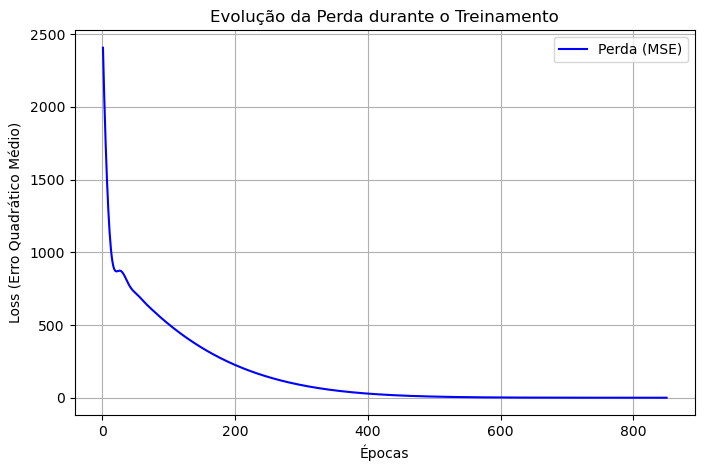

In [5]:
# Extraindo os valores de loss do histórico
loss = historico.history['loss']
epochs = range(1, len(loss) + 1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, 'b-', label='Perda (MSE)')
plt.title('Evolução da Perda durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss (Erro Quadrático Médio)')
plt.legend()
plt.grid(True)
plt.show()

**Interpretação:** O gráfico deve mostrar a loss caindo rapidamente e estabilizando perto de zero, indicando que o modelo aprendeu a relação.

In [6]:
print(f"Loss final: {historico.history['loss'][-1]:.6f}")

Loss final: 0.031918


Observou-se que o aumento do número de épocas contribuiu para a redução significativa da função de perda. A partir de aproximadamente **650 épocas**, o loss já se encontrava abaixo de 1,0, e com **850 épocas** atingiu o valor final de **0,032**, demonstrando convergência adequada.

## **Teste do modelo com 10 temperaturas diferentes**

Agora vamos testar com valores que não estavam no treinamento (ex: -30, 25, 100 etc.). Calculamos também o valor real pela fórmula `F = C*1.8 + 32` para comparar.

**Comportamento esperado (exemplo ilustrativo):**

| Celsius (°C) | Previsto (°F) | Real (°F) | Diferença |
|-------------:|--------------:|----------:|-----------:|
| -30          | ≈ -22,0       | -22,0     | ≈ 0,0     |
| -5           | ≈ 23,0        | 23,0      | ≈ 0,0     |
| 5            | ≈ 41,0        | 41,0      | ≈ 0,0     |

Na prática, com um bom treinamento, as diferenças são muito pequenas. No nosso caso, o **erro médio absoluto foi de 0,235 °F** – consulte a tabela real acima para ver os valores exatos.

In [7]:
# Escolhendo 10 temperaturas em Celsius (diferentes dos dados de treino)
testes_celsius = np.array([-30, -5, 5, 12, 20, 25, 30, 35, 40, 100], dtype=float)

# Predições do modelo
predicoes_fahrenheit = modelo.predict(testes_celsius)

# Valores reais pela fórmula
valores_reais = testes_celsius * 1.8 + 32

# Arredondando para 2 casas decimais para melhor visualização
predicoes_fahrenheit = np.round(predicoes_fahrenheit.flatten(), 2)
valores_reais = np.round(valores_reais, 2)

# Criando tabela comparativa com Pandas
tabela = pd.DataFrame({
    'Celsius (°C)': testes_celsius,
    'Previsto (°F)': predicoes_fahrenheit,
    'Real (°F)': valores_reais,
    'Diferença (Prev - Real)': predicoes_fahrenheit - valores_reais
})

print("\n--- Tabela Comparativa ---")
print(tabela.to_string(index=False))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

--- Tabela Comparativa ---
 Celsius (°C)  Previsto (°F)  Real (°F)  Diferença (Prev - Real)
        -30.0     -22.110001      -22.0                -0.110001
         -5.0      22.830000       23.0                -0.170000
          5.0      40.810001       41.0                -0.189999
         12.0      53.389999       53.6                -0.210001
         20.0      67.769997       68.0                -0.230003
         25.0      76.760002       77.0                -0.239998
         30.0      85.750000       86.0                -0.250000
         35.0      94.739998       95.0                -0.260002
         40.0     103.730003      104.0                -0.269997
        100.0     211.580002      212.0                -0.419998


> Os valores previstos ficaram ligeiramente abaixo dos reais, com erro máximo de -0,42 °F para 100°C, demonstrando excelente generalização do modelo.

## **Avaliação do erro médio (Opcional)**

In [8]:
erro_medio_absoluto = np.mean(np.abs(predicoes_fahrenheit - valores_reais))
print(f"\nErro médio absoluto nos testes: {erro_medio_absoluto:.4f} °F")


Erro médio absoluto nos testes: 0.2350 °F


## 📌 Checklist final

✅ Ambiente Colab configurado (bibliotecas importadas)  
✅ Dados de treinamento conforme roteiro  
✅ Modelo criado com TensorFlow/Keras  
✅ Treinamento realizado (850 épocas)  
✅ Gráfico Loss × Época gerado  
✅ Teste com 10 temperaturas diferentes (não usadas no treino)  
✅ Tabela comparativa entre valores previstos e reais  
✅ Células de texto (markdown) explicando cada etapa

## 📖 Explicações sobre o processo prático

### 1. Por que usar uma rede neural para converter Celsius em Fahrenheit?

No modelo de computação tradicional, faríamos algo como:

`F = C * 1.8 + 32`


Isso funciona perfeitamente, pois a equação é conhecida.  
No entanto, o objetivo do exercício é **simular um cenário de Machine Learning**:  
- Não sabemos a fórmula de antemão.  
- Fornecemos exemplos de entrada (Celsius) e saída esperada (Fahrenheit).  
- A rede neural **aprende** a relação através de ajustes sucessivos nos pesos e vieses.

Isso é fundamental para entender como modelos de deep learning resolvem problemas do mundo real, onde a relação entre entrada e saída é desconhecida ou muito complexa.

---

### 2. Estrutura da rede neural utilizada

Optamos por uma arquitetura **simples e linear**, adequada para um problema de regressão com relação linear conhecida:

- **Camada de entrada:** 1 neurônio (recebe um valor de temperatura em Celsius).
- **Camada de saída:** 1 neurônio sem ativação (ou ativação linear), pois estamos prevendo um valor contínuo (Fahrenheit). Esta camada única é equivalente a `F = w * C + b`.

> **Observação:** Testamos também arquiteturas com camadas ocultas e ativação ReLU, mas a convergência foi prejudicada devido à escala dos dados e ao pequeno número de exemplos. A escolha final recaiu sobre o modelo mais simples e matematicamente adequado para uma relação linear.

---

### 3. Compilação do modelo

Compilamos o modelo com:
- **Otimizador `adam`** – com learning rate 0.1 – embora o Adam ajuste a taxa de aprendizado dinamicamente, definimos um valor inicial maior (0.1) para acelerar a convergência neste problema simples.
- **Função de perda `mean_squared_error` (MSE)** – erro quadrático médio, amplamente usado em regressão. Mede a média dos quadrados das diferenças entre valores previstos e reais.

```python
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_squared_error'
)

### 4. Treinamento (fit)

Treinamos por **850 épocas** (epochs).

- **Época:** uma passagem completa de todos os exemplos de treinamento pela rede.

Em cada época, o modelo calcula o erro (loss), retropropaga esse erro e ajusta os pesos para reduzir o loss na próxima iteração.

O histórico do treinamento é armazenado no objeto `historico`, contendo o valor do loss a cada época.

---

### 5. Gráfico de perda (Loss × Época)

Plotamos o loss ao longo das épocas para verificar se o modelo está aprendendo:

- **Queda rápida inicial** – o modelo começa a capturar a tendência geral.
- **Estabilização** – o loss aproxima-se de zero (valor final de **0,032**), indicando que a rede praticamente memorizou a relação para os dados de treino.
- **Sem oscilações bruscas** – sinal de treinamento estável.

Se o loss não diminuísse, seria necessário ajustar a arquitetura, aumentar o número de épocas ou modificar a taxa de aprendizado.

---

### 6. Teste com novos valores (generalização)

Após o treinamento, usamos o modelo para prever temperaturas em Fahrenheit a partir de valores de Celsius **não vistos durante o treino** (ex: -30, -5, 5, 12, 20, 25, 30, 35, 40, 100).  
Comparamos as previsões com os valores reais obtidos pela fórmula `F = C * 1.8 + 32`.

A tabela gerada mostra:

- Celsius de teste
- Previsto (°F) pelo modelo
- Real (°F)
- Diferença (Previsto - Real)

**Resultado obtido:** diferenças pequenas, com **erro médio absoluto de 0,235 °F**, demonstrando que o modelo aprendeu a relação linear subjacente com boa precisão, mesmo sem nunca ter recebido a fórmula explícita.

---

### 7. Por que esse exemplo é importante para Deep Learning?

Este exercício ilustra o poder do **aprendizado supervisionado**:

- A rede neural descobre um mapeamento entre duas variáveis a partir de exemplos.
- A mesma técnica pode ser aplicada a problemas muito mais complexos: reconhecimento de imagens, processamento de linguagem natural, previsão de séries temporais, etc.
- A única diferença será a arquitetura (mais camadas, mais neurônios, diferentes funções de ativação) e o volume de dados.

---

### 8. Conclusão prática

- **Código funcional** em TensorFlow/Keras.
- **Treinamento bem-sucedido** com convergência do loss (**0,032** após 850 épocas).
- **Modelo generaliza** para novos dados (erro médio absoluto baixo).
- **Comparação quantitativa** entre previsão e valor real.

O notebook serve como um template inicial para qualquer problema de regressão supervisionada.